<a href="https://colab.research.google.com/github/vm24aat/appliedDataScience/blob/main/Copy_of_GroupQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [2]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [3]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [4]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

# Pre-Processing

In [5]:
# STEP 4: Check Missing Values

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [6]:
# STEP 5: Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [7]:
# Separate categorical and numerical columns

categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

# Fill categorical missing values
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Fill numerical missing values
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [8]:
# Check remaining missing values

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [10]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical variables into numerical format

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0,1,3.0,2.0,0,4,4,2.0,3,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,2,0.0,0.0,0,5,2,1.0,4,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,2,2,5.0,21,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1,0,1.0,0.0,1,3,3,2.0,0,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,0.0,0,3,2,2.0,21,0


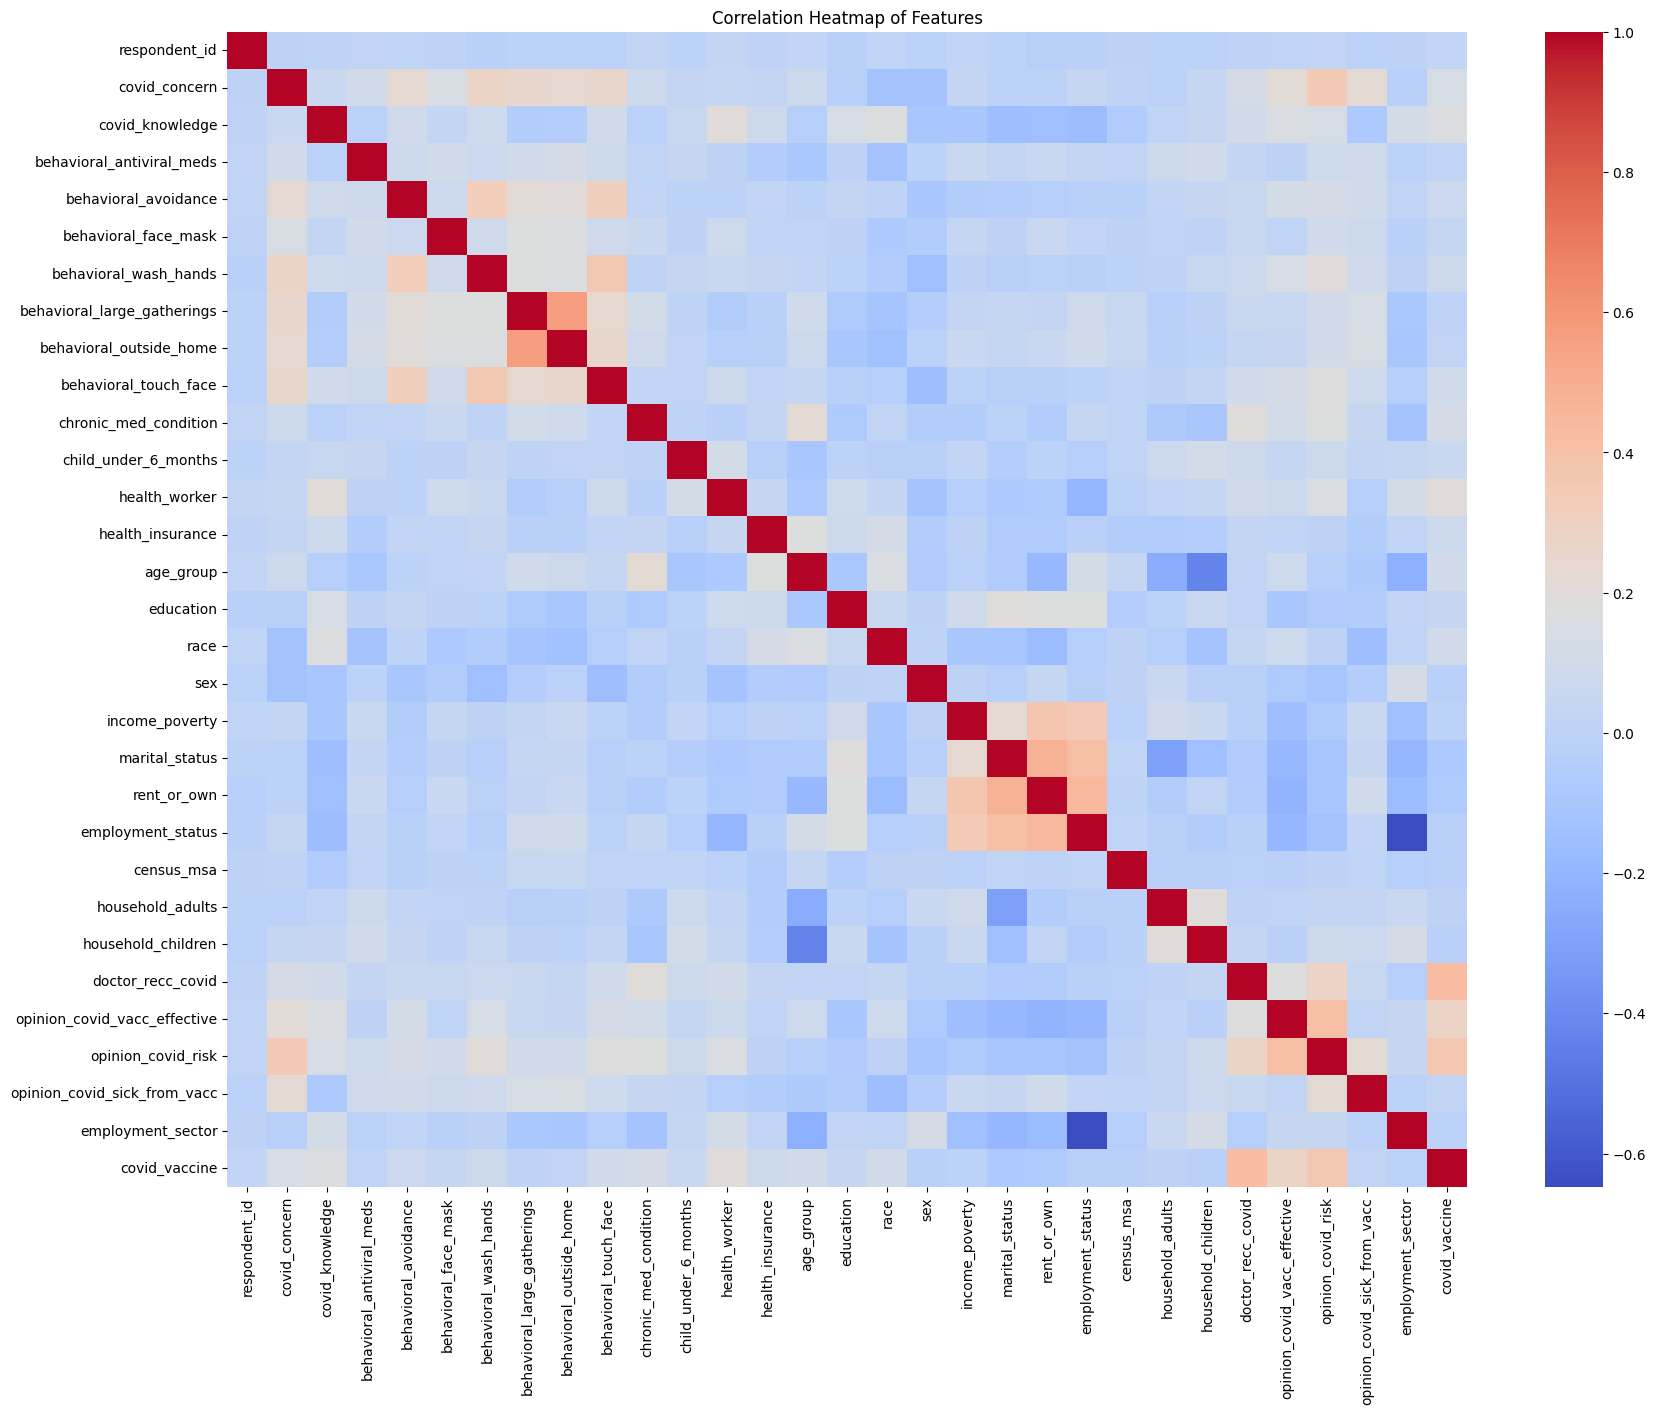

In [12]:
import seaborn as sns

plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [13]:
# Create feature matrix and target variable

X = df.drop("covid_vaccine", axis=1)
y = df["covid_vaccine"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4756, 30)
Target Shape: (4756,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (3804, 30)
Testing Set: (952, 30)


In [16]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [21]:
model = {
    "Random Forest": (rf, y_pred_rf),
}


🔹 Random Forest 🔹
Accuracy: 0.7857142857142857
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       641
           1       0.74      0.54      0.62       311

    accuracy                           0.79       952
   macro avg       0.77      0.72      0.74       952
weighted avg       0.78      0.79      0.78       952



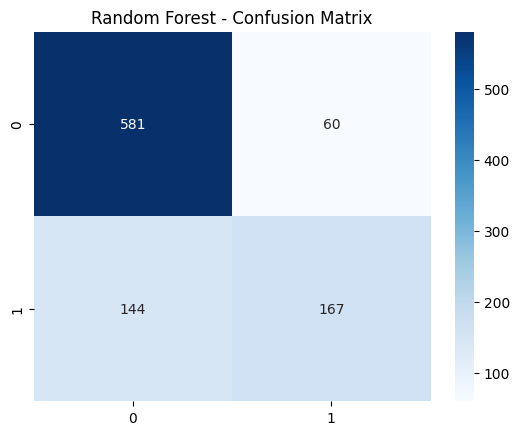

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, (model, y_pred) in model.items():
    print(f"\n🔹 {name} 🔹")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

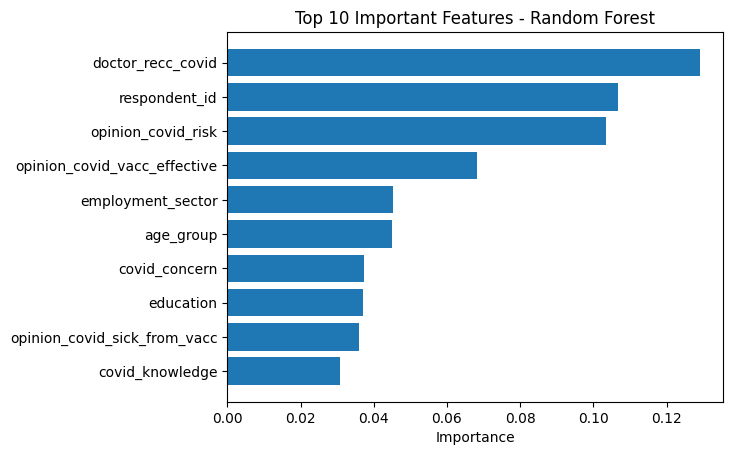

In [24]:
# Feature Importance

importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]  # top 10 important features
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel('Importance')
plt.title('Top 10 Important Features - Random Forest')
plt.show()

In [28]:
# Multiple performance metrics (Train vs Test metrics, plus confusion matrix + report)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import pandas as pd
import numpy as np

def _avg_mode(y_true):
    return "binary" if len(np.unique(y_true)) == 2 else "weighted"

def metrics_table(y_true, pred_dict, label="TEST"):
    rows = []
    avg = _avg_mode(y_true)
    for name, y_pred in pred_dict.items():
        rows.append({
            "Model": name,
            f"{label}_Accuracy":  accuracy_score(y_true, y_pred),
            f"{label}_Precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
            f"{label}_Recall":    recall_score(y_true, y_pred, average=avg, zero_division=0),
            f"{label}_F1":        f1_score(y_true, y_pred, average=avg, zero_division=0),
        })
    return pd.DataFrame(rows).sort_values(by=f"{label}_F1", ascending=False).reset_index(drop=True)

# Reconstruct the model dictionary just in case it was overwritten
# Assuming 'rf' and 'y_pred_rf' are available from previous cells
model = {
    "Random Forest": (rf, y_pred_rf),
}

# Extract the trained model and test predictions from the 'model' dictionary
rf_model = model["Random Forest"][0]
y_pred_rf_test = model["Random Forest"][1]

# Make predictions on the training data
y_pred_rf_train = rf_model.predict(X_train)

# Create prediction dictionaries
train_preds = {"Random Forest": y_pred_rf_train}
test_preds = {"Random Forest": y_pred_rf_test}

train_metrics_df = metrics_table(y_train, train_preds, label="TRAIN")
test_metrics_df   = metrics_table(y_test,  test_preds,  label="TEST")

print("TRAIN METRICS")
display(train_metrics_df)

print("\nTEST METRICS")
display(test_metrics_df)

# Show detailed report + confusion matrix for best test F1 model
best_model_name = test_metrics_df.loc[0, "Model"]
print(f"\nBest model on TEST (by F1): {best_model_name}")

print("\nConfusion Matrix (TEST):")
print(confusion_matrix(y_test, test_preds[best_model_name]))

print("\nClassification Report (TEST):")
print(classification_report(y_test, test_preds[best_model_name], zero_division=0))

TRAIN METRICS


,Model,TRAIN_Accuracy,TRAIN_Precision,TRAIN_Recall,TRAIN_F1
0,Random Forest,1.0,1.0,1.0,1.0



TEST METRICS


,Model,TEST_Accuracy,TEST_Precision,TEST_Recall,TEST_F1
0,Random Forest,0.785714,0.735683,0.536977,0.620818



Best model on TEST (by F1): Random Forest

Confusion Matrix (TEST):
[[581  60]
 [144 167]]

Classification Report (TEST):
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       641
           1       0.74      0.54      0.62       311

    accuracy                           0.79       952
   macro avg       0.77      0.72      0.74       952
weighted avg       0.78      0.79      0.78       952



### Generate Submission File

In [31]:
# Load the test dataset
import pandas as pd
test_df = pd.read_csv('/content/dataset_C_testing.csv')

# Store original respondent_id for the submission file
submission_ids = test_df['respondent_id']

print("Test dataset loaded and respondent_ids stored.")

Test dataset loaded and respondent_ids stored.


In [32]:
# Preprocessing: Handle Missing Values for the Test Data
# Use the same categorical_columns and numerical_columns identified from the training data.

# Fill missing categorical values in test_df with "Unknown"
for col in categorical_columns:
    test_df[col] = test_df[col].fillna("Unknown")

# Fill missing numerical values in test_df using medians from the training features (X).
# X represents the preprocessed training feature matrix, so its medians are appropriate for imputation.
for col in numerical_columns:
    # Skip 'covid_vaccine' as it's the target and not present in the test_df features
    if col != 'covid_vaccine':
        test_df[col] = test_df[col].fillna(X[col].median())

print("Missing values in test dataset imputed.")

Missing values in test dataset imputed.


In [33]:
from sklearn.preprocessing import LabelEncoder

# Preprocessing: Apply Label Encoding to test_df's categorical columns.
# To maintain consistency with how the training data was processed (where `LabelEncoder`
# was re-fit for each categorical column in `df`), we will re-instantiate and
# `fit_transform` LabelEncoder for each corresponding column in `test_df`.
# NOTE: This approach fits LabelEncoder on the test data, which can lead to data leakage
# if the test set contains categories not present in the training set or if the order of labels differs.
# A more robust solution would store and reuse LabelEncoders fitted only on training data.
for col in categorical_columns:
    le_for_test = LabelEncoder() # Create a new instance for each column
    test_df[col] = le_for_test.fit_transform(test_df[col])

print("Categorical features in test dataset label encoded.")

Categorical features in test dataset label encoded.


In [34]:
# Preprocessing: Feature Scaling for the Test Data
# Ensure test_df has the same columns and order as X (training features) before scaling.
test_df_processed = test_df[X.columns]

# Apply the StandardScaler fitted on the training data (`scaler`) to the processed test_df.
X_test_scaled_submission = scaler.transform(test_df_processed)

print("Test dataset features scaled.")

Test dataset features scaled.


In [35]:
# Make predictions on the preprocessed and scaled test data using the trained Random Forest model (`rf`)
final_predictions = rf.predict(X_test_scaled_submission)

print("Predictions made on the test dataset.")

Predictions made on the test dataset.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [36]:
# Create the submission DataFrame
submission_df = pd.DataFrame({
    'respondent_id': submission_ids,
    'covid_vaccine': final_predictions
})

# Save the submission DataFrame to a CSV file
submission_filename = 'challenge_submission_group_Q_5.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully.")
print("First 5 rows of the submission file:")
print(submission_df.head())

Submission file 'challenge_submission_group_Q_5.csv' created successfully.
First 5 rows of the submission file:
   respondent_id  covid_vaccine
0           4757              0
1           4758              0
2           4759              0
3           4760              0
4           4761              0
